# 6 Test Environment Impassible Terrain

Building on from the previous notepads I intend to add impassible terrain to this model, This can be used to represent listed buildings or areas that cannot be demolished such a protected forests for a train-line. 

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path, find_feasible_initial_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)


terrain.add_hill(
    centre=(50, 50),
    peak_cost=300,
    radius=30
)

terrain.add_impassable_square(
    bottom_left=(30,40),
    top_right=(40,50),
)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

initial_path = find_feasible_initial_path(
    initial_path,
    terrain,
    sigma=3,
    alpha=10,
    max_attempts=10000
)

initial_path_df = initial_path.to_dataframe()

Feasible path found after 100 attempts


In [2]:
print(terrain.impassable)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


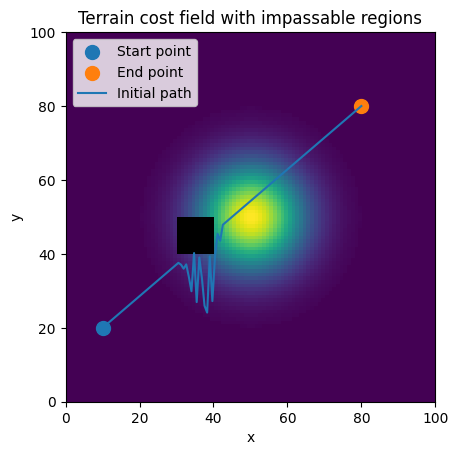

In [3]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot only impassable cells
plt.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot(
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with impassable regions")

plt.legend()
plt.show()

In [4]:
from cost_functions.terrain_cost import terrain_cost, terrain_curvature_cost, terrain_length_cost




print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))


10190.084997294734
3546.359347477886
190.01347708001117


The purpose of this notepad is to work out normalised weightings for this function and to experiment with the results. Our weight vector contains $(w_c,\lambda,\mu)$.

My plan is turn my objective fucntion into the following 
$$
J(\gamma) = \frac{w_c}{C_0(\gamma)}C(\gamma) + \frac{\lambda}{K_0(\gamma)}K(\gamma) + \frac{\mu}{L_0(\gamma)}L(\gamma)
$$
Where 
$$
w_c + \lambda + \mu = 1
$$

Using the initial weights will not work as the curvature initial cost $K_0$ is so small diving by it will explode the value of lambda. I'm going to apply a fixed amount of random perturbations to get a better value for the weights. 

In [5]:
from optimisation.moves import segment_shift_move

terrain_scale = np.mean([
    terrain_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10), terrain)
    for _ in range(50)
])

curvature_scale = np.mean([
    terrain_curvature_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

length_scale = np.mean([
    terrain_length_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

terrain_scale_std = np.std([
    terrain_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10), terrain)
    for _ in range(50)
])

curvature_scale_std = np.std([
    terrain_curvature_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

length_scale_std = np.std([
    terrain_length_cost(segment_shift_move(path=initial_path, terrain=terrain, sigma=0.3, alpha =10))
    for _ in range(50)
])

print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))

print(terrain_scale)
print(curvature_scale)
print(length_scale)

print(terrain_scale_std)
print(curvature_scale_std)
print(length_scale_std)

10190.084997294734
3546.359347477886
190.01347708001117
10246.266617837056
3548.3992254927502
189.95669829511155
68.70339222530481
11.337884289013958
0.40359116812344004


In [6]:
sample_paths = [
    segment_shift_move(
        path=initial_path,
        terrain=terrain,
        sigma=0.3,
        alpha=10
    )
    for _ in range(1000)
]

terrain_values = [
    terrain_cost(p, terrain)
    for p in sample_paths
]

curvature_values = [
    terrain_curvature_cost(p)
    for p in sample_paths
]

length_values = [
    terrain_length_cost(p)
    for p in sample_paths
]


terrain_scale = np.mean(terrain_values)
curvature_scale = np.mean(curvature_values)
length_scale = np.mean(length_values)

print(terrain_scale)
print(curvature_scale)
print(length_scale)

10249.110498976379
3546.399921933254
190.01276140179846


In [7]:
from cost_functions.terrain_cost import terrain_cost, total_cost

w_c = 0.6/terrain_scale
lam = 0.3/curvature_scale
mu = 0.1/length_scale

print(total_cost(
                        initial_path,
                        terrain,
                        w_c,
                        lam,
                        mu
                    ))

0.9965414931554716


In [8]:
terrain_component = w_c * terrain_cost(initial_path, terrain)
curvature_component = lam * terrain_curvature_cost(initial_path)
length_component = mu * terrain_length_cost(initial_path)

print(terrain_component)
print(curvature_component)
print(length_component)
print(sum([
    terrain_component,
    curvature_component,
    length_component
]))

0.5965445488159656
0.29999656769206
0.10000037664744592
0.9965414931554716


In [22]:
from optimisation.annealing import simulated_segment_annealing_curvature


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing_curvature(
    initial_path=initial_path,
    terrain=terrain,
    iterations=50000,          # was 10000
    initial_temperature=100,    # slightly lower than 100
    cooling_rate=0.9992,       # slower cooling
    sigma=0.9,                 # much bigger than 0.3 to escape spike basins
    alpha=10,
    terrain_weight=w_c,
    lam=lam,
    mu=mu,
    segment_length=7,          # larger local repair window
    max_candidate_attempts=4,  # keep runtime controlled
    retry_sigma_decay=0.7
)


=== Annealing Parameters ===
Terrain weight (w_c): 5.854166564600162e-05
Curvature weight (lambda): 8.459282839044858e-05
Length weight (mu): 0.0005262804417043408
Initial cost: 0.9965414931554716

Iteration: 0
Current cost: 0.9965414931554716
Candidate cost: 0.997489858801267
Delta: 0.0009483656457953682
Candidate sigma: 0.9
Candidate components:
Terrain: 10336.946961144926
Curvature: 3463.13665818695
Length: 188.85604158291153

Iteration: 1
Current cost: 0.997489858801267
Candidate cost: 1.003178620195328
Delta: 0.005688761394061159
Candidate sigma: 0.3086999999999999
Candidate components:
Terrain: 10514.904203236683
Curvature: 3411.070732785045
Length: 188.23897878993722

Iteration: 2
Current cost: 1.003178620195328
Candidate cost: 0.9942906883413748
Delta: -0.008887931853953313
Candidate sigma: 0.3086999999999999
Candidate components:
Terrain: 10367.819884514376
Curvature: 3407.175164703408
Length: 188.33810137276032

Iteration: 3
Current cost: 0.9942906883413748
Candidate cost: 0.

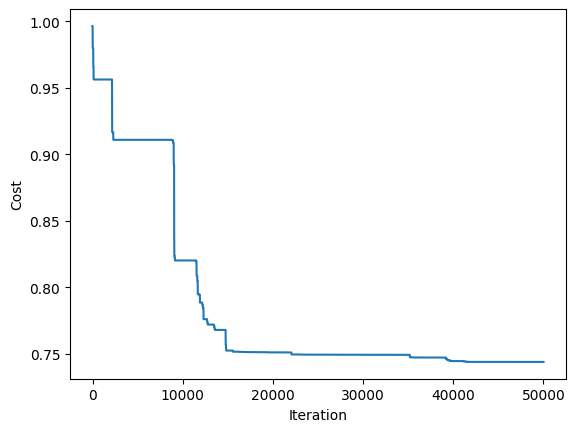

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [24]:

best_path_segment_df = best_path_segment.to_dataframe()


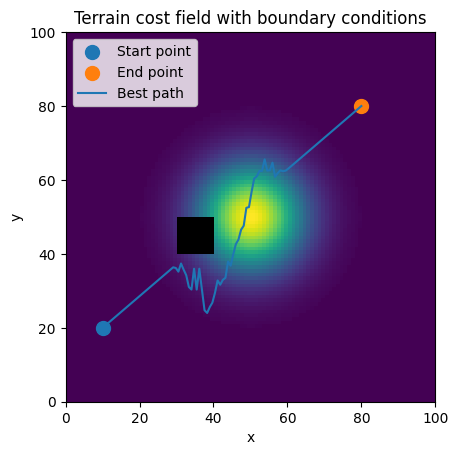

In [25]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)
# Plot only impassable cells
plt.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [26]:
print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))
print(total_cost(initial_path,terrain, w_c, lam, mu))



print(terrain_cost(best_path_segment, terrain))
print(terrain_curvature_cost(best_path_segment))
print(terrain_length_cost(best_path_segment))
print(total_cost(best_path_segment,terrain, w_c, lam, mu))

10190.084997294734
3546.359347477886
190.01347708001117
0.9965414931554716
10181.272082201878
770.6332241958204
157.34437796674223
0.74402593890964


In [27]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.707071 20.606061
     2 11.414141 21.212121
     3 12.121212 21.818182
     4 12.828283 22.424242
     5 13.535354 23.030303
     6 14.242424 23.636364
     7 14.949495 24.242424
     8 15.656566 24.848485
     9 16.363636 25.454545
    10 17.070707 26.060606
    11 17.777778 26.666667
    12 18.484848 27.272727
    13 19.191919 27.878788
    14 19.898990 28.484848
    15 20.606061 29.090909
    16 21.313131 29.696970
    17 22.020202 30.303030
    18 22.727273 30.909091
    19 23.434343 31.515152
    20 24.141414 32.121212
    21 24.848485 32.727273
    22 25.555556 33.333333
    23 26.262626 33.939394
    24 26.969697 34.545455
    25 27.676768 35.151515
    26 28.383838 35.757576
    27 29.090909 36.363636
    28 29.797980 36.186082
    29 30.505051 35.196868
    30 31.212121 37.397588
    31 31.919192 35.739121
    32 32.626263 34.239399
    33 33.333333 31.049257
    34 34.040404 30.357673
    35 34.747475 35.987215
 

In [28]:
print(len(path_history_segment))

9492


In [29]:
import numpy as np
import pandas as pd

from cost_functions.terrain_cost import (
    terrain_cost,
    terrain_curvature_cost,
    terrain_length_cost,
    total_cost
)

def segment_diagnostics(path, terrain):
    pts = path.points
    rows = []
    for i in range(len(pts) - 1):
        p1 = pts[i]
        p2 = pts[i + 1]
        seg_vec = p2 - p1
        seg_len = np.linalg.norm(seg_vec)
        midpoint = 0.5 * (p1 + p2)
        c_mid = terrain.get_cost_at_coordinate(midpoint[0], midpoint[1])
        terrain_contrib = c_mid * seg_len

        rows.append({
            "seg": i,
            "x1": p1[0], "y1": p1[1],
            "x2": p2[0], "y2": p2[1],
            "seg_len": seg_len,
            "terrain_mid_cost": c_mid,
            "terrain_contrib": terrain_contrib,
            "dy": p2[1] - p1[1]
        })

    df = pd.DataFrame(rows)

    # pointwise discrete curvature contribution at interior points
    curv_rows = []
    for i in range(1, len(pts)-1):
        kvec = pts[i+1] - 2*pts[i] + pts[i-1]
        k2 = np.linalg.norm(kvec) ** 2
        curv_rows.append({"point": i, "curv_contrib": k2})
    curv_df = pd.DataFrame(curv_rows)

    return df, curv_df

def print_path_summary(name, path, terrain, w_c, lam, mu):
    tc = terrain_cost(path, terrain)
    kc = terrain_curvature_cost(path)
    lc = terrain_length_cost(path)
    J = total_cost(path, terrain, w_c, lam, mu)

    print(f"\n=== {name} ===")
    print(f"Terrain cost C:    {tc:.6f}")
    print(f"Curvature cost K:  {kc:.6f}")
    print(f"Length cost L:     {lc:.6f}")
    print(f"Total J:           {J:.6f}")
    print(f"Weighted: w_c*C={w_c*tc:.6f}, lam*K={lam*kc:.6f}, mu*L={mu*lc:.6f}")

# ---- run ----
print_path_summary("INITIAL", initial_path, terrain, w_c, lam, mu)
print_path_summary("BEST", best_path_segment, terrain, w_c, lam, mu)

initial_seg_df, initial_curv_df = segment_diagnostics(initial_path, terrain)
best_seg_df, best_curv_df = segment_diagnostics(best_path_segment, terrain)

# Top spike indicators
print("\nTop 15 longest BEST segments:")
print(best_seg_df.sort_values("seg_len", ascending=False).head(15)[["seg","seg_len","dy","terrain_mid_cost","terrain_contrib"]])

print("\nTop 15 curvature contributors in BEST:")
print(best_curv_df.sort_values("curv_contrib", ascending=False).head(15))

# If you want full tables:
initial_path_df = initial_path.to_dataframe()
best_path_segment_df = best_path_segment.to_dataframe()

print("\nInitial path points (head):")
print(initial_path_df.head(15))
print("\nBest path points (head):")
print(best_path_segment_df.head(15))


=== INITIAL ===
Terrain cost C:    10190.084997
Curvature cost K:  3546.359347
Length cost L:     190.013477
Total J:           0.996541
Weighted: w_c*C=0.596545, lam*K=0.299997, mu*L=0.100000

=== BEST ===
Terrain cost C:    10181.272082
Curvature cost K:  770.633224
Length cost L:     157.344378
Total J:           0.744026
Weighted: w_c*C=0.596029, lam*K=0.065190, mu*L=0.082807

Top 15 longest BEST segments:
    seg   seg_len        dy  terrain_mid_cost  terrain_contrib
36   36  5.674759  5.630536         21.609912       122.631045
35   35  5.674667 -5.630444         18.557453       105.307376
37   37  5.674602 -5.630379         24.912720       141.369780
34   34  5.673773  5.629543         18.557453       105.290775
38   38  5.648074 -5.603641          9.044621        51.084690
54   54  4.903757  4.852513        296.199423      1452.489890
47   47  4.474787  4.418571         82.807908       370.547730
56   56  4.164834  4.104375        270.220436      1125.423230
65   65  3.898689 

Animation for posting and showing Yasemin

In [17]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Reduce frames for LinkedIn
linkedin_history = path_history_segment[::2]


fig, ax = plt.subplots(figsize=(6, 6))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot only impassable cells
ax.imshow(
    np.ma.masked_where(
        ~terrain.impassable,
        terrain.impassable
    ),
    extent=[0, terrain.width, 0, terrain.height],
    origin="lower",
    cmap=ListedColormap(["black"])

)


# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    s=80,
    label="Start"
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    s=80,
    label="End"
)

# Empty path line
line, = ax.plot(
    [],
    [],
    linewidth=2,
    label="Optimised path"
)

# Iteration counter
iteration_text = ax.text(
    0.02,
    0.90,
    "",
    transform=ax.transAxes,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Optimisation")

ax.legend()


def update(frame):

    path = linkedin_history[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    # Calculate current path cost
    current_cost = total_cost(
        path,
        terrain,
        w_c,
        lam,
        mu
    )

    # Recover original iteration number
    iteration_text.set_text(
        f"Iteration: {frame * 2}\n"
        f"Cost: {current_cost:.2f}"
    )

    return line, iteration_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(linkedin_history),
    interval=50,
    blit=True
)


animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/linkedin_path_impassible_terrain.gif",
    writer="pillow",
    fps=40
)

plt.close()